<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Semantic Segmentation
The original code for this exercise was written by Arunava Chakraborty and published as a tutorial on [LearnOpenCV.com](https://www.learnopencv.com/pytorch-for-beginners-semantic-segmentation-using-torchvision/). The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Jan
- LastName: Hoegen
- MatriculationNumber: 82358


In this exercise, you will learn how to apply a convolutional neural network for semantic segmentation.

----------

## What is Semantic Segmentation?

Semantic Segmentation is an image analysis task in each pixel of an image is classified into a class.
Similar to what us humans do all the time by default, when are looking whatever we are seeing. 

Let's say we have the following image:

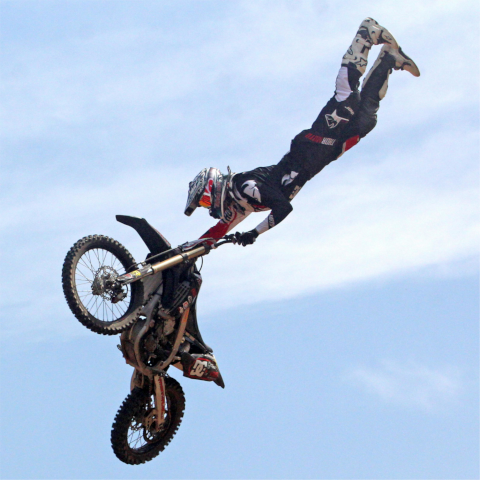

Source: Pexels

The semantically segmentated image would be the following:

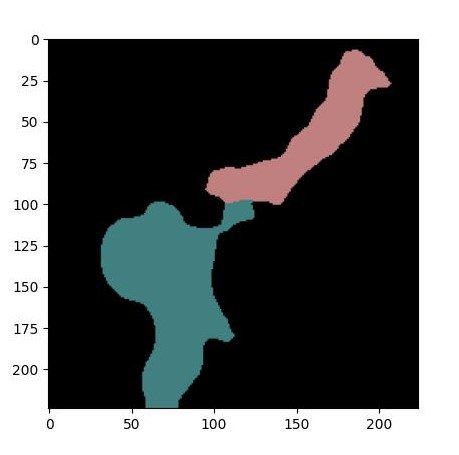

As you can see, that each pixel in the image is classified to its respective class (turquoise: motorbike, pink: person, black: background). This is in most simple terms what Semantic Segmentation is.

## Using Pytorch for Semantic Segmentation

Before we get started, we need to define the inputs and outputs of a semantic segmentation model.

We want the input to be an image, therefore the model shoud expect a 3-channel image (red, green, blue) which is normalized with the Imagenet mean and standard deviation, i.e.: `mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]`

So, the input is `[Ni x Ci x Hi x Wi]`<br/>
where,
- `Ni` -> the batch size
- `Ci` -> the number of channels (which is 3)
- `Hi` -> the height of the image
- `Wi` -> the width of the image

We want the output to be also an image, therefore the model shoud output the class information along with the spatial information. 

So the output of the model could be `[No x Co x Ho x Wo]` where,
- `No` -> is the batch size (same as `Ni`)
- `Co` -> **is the number of classes that the dataset have!**
- `Ho` -> the height of the image (which is the same as `Hi` in almost all cases)
- `Wo` -> the width of the image (which is the same as `Wi` in almost all cases)

With `Co` the number of classes in the output, we need to deal with it later to form an output image. 

In this excercise we are using an existing model based on Resnet-101.

## Init

Let's do the usual initialization. 

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import pynvml as py

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## CPU or GPU

As PyTorch can execute on a GPU, the following section detects if there is a Cuda-GPU avaiable.
Otherwise the CPU is used. 

In [2]:
# Helper function to find the GPU with max. free memory left

def get_gpu_with_max_free_mem():
    py.nvmlInit()
    mem_free = np.zeros(torch.cuda.device_count())
    for gpu_index in range(torch.cuda.device_count()):
        handle = py.nvmlDeviceGetHandleByIndex(int(gpu_index))
        mem_info = py.nvmlDeviceGetMemoryInfo(handle)
        mem_free[gpu_index] = mem_info.free // 1024 ** 2
        
    GPU_num = np.argmax(mem_free)
    return GPU_num

In [3]:
USE_GPU = True

dtype = torch.float32 # we will be using float throughout this tutorial

if USE_GPU and torch.cuda.is_available():
    print('***********************************')
    print('GPU availble! Lets see what we have:')
    print('***********************************')
    !nvidia-smi
    print('***********************************')
    device = torch.device('cuda:' + str(get_gpu_with_max_free_mem()))
    print('Using GPU with max free memory: ' + str(get_gpu_with_max_free_mem()))
    print(device)
    print('***********************************')
else:
    device = torch.device('cpu')
    print('no GPU available, using {} with {} threads'.format(device, torch.get_num_threads()))

***********************************
GPU availble! Lets see what we have:
***********************************
Tue Oct 28 16:56:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   45C    P2             41W /  165W |    1981MiB /  16380MiB |      7%      Default |
|                              

### Segmentation with Resnet-101 backbone

In this exercise we are going to use a pretrained network optimized for the segmentation. 
The network is included in the torchvision model zoo. For an in-depth overview check the support page at: https://pytorch.org/vision/stable/models.html#semantic-segmentation

In [4]:
# load the model. 
fcn = models.segmentation.fcn_resnet101(pretrained=True).eval()

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fcn_resnet101_coco-7ecb50ca.pth" to C:\Users\Jax/.cache\torch\hub\checkpoints\fcn_resnet101_coco-7ecb50ca.pth


100%|██████████| 208M/208M [01:22<00:00, 2.65MB/s] 


Now, let's get an image!

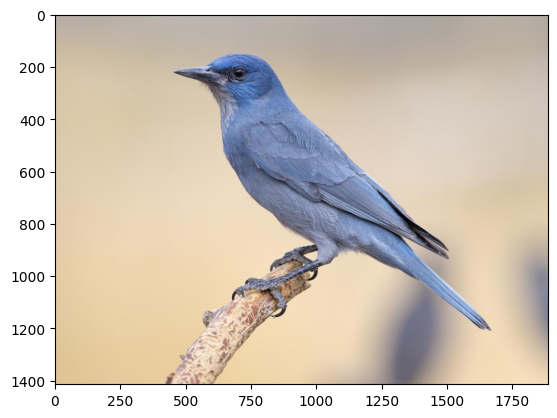

In [5]:
img = Image.open('./EITB712M/bird.jpg')
plt.imshow(img); plt.show()

Now, that we have the image we need to preprocess it and normalize it. <br/>
So, for the preprocessing steps, we:
- Resize the image to `(256 x 256)`
- CenterCrop it to `(224 x 224)`
- Convert it to Tensor - all the values in the image becomes between `[0, 1]` from `[0, 255]`
- Normalize it with the Imagenet specific values `mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]`

And lastly, we unsqueeze the image so that it becomes `[1 x C x H x W]` from `[C x H x W]`. The extra batch dimension is required while passing it to the models.

`T.Compose` is a function that takes in a `list` in which each element is of `transforms` type and it returns a object through which we can
pass batches of images and all the required transforms will be applied to the images.

Let's take a look at the transforms applied on the images:
- `T.Resize(256)` : Resizes the image to size `256 x 256`
- `T.CenterCrop(224)` : Center Crops the image to have a resulting size of `224 x 224`
- `T.ToTensor()` : Converts the image to type `torch.Tensor` and have values between `[0, 1]`
- `T.Normalize(mean, std)` : Normalizes the image with the given mean and standard deviation.

In [6]:
# Apply the transformations needed
trf = T.Compose([T.Resize(256),
                 T.CenterCrop(224),
                 T.ToTensor(), 
                 T.Normalize(mean = [0.485, 0.456, 0.406], 
                             std = [0.229, 0.224, 0.225])])
inp = trf(img).unsqueeze(0)

Now it is time to pass the image through the model (inference). 

The model returns an OrderedDict with two Tensors that are of the same height and width as the input Tensor, but with 21 classes. output `['out']` contains the semantic masks, and output `['aux']` contains the auxillary loss values per-pixel. In inference mode, output `['aux']` is not useful. So, output `['out']` is of shape `[N, 21, H, W]`. We directly select the semantic mask by adding `['out']` to the interence command.

In [7]:
# Pass the input through the net
out = fcn(inp)['out']
print (out.shape)

torch.Size([1, 21, 224, 224])


`out` is the output of the model. And as we can see, its shape is `[1 x 21 x H x W]`. This means the model was trained on `21` classes and thus our output of `N=1` image has `21` channels. Each channel then contains the classification result for each class, spacially within each pixel. 

To visualize the classification result we want to transform this `21` channeled output into an image with `3` channeles `RGB`. Additionally the color of a pixel should corresponds to a class!

In a first step we apply the classification to each pixel. This means we take a max index for each pixel position, which then represents the class `0 - 20`. 

In [8]:
om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy() # here we apply the classification
print (om.shape) # show the shape of the output containing class labels
print (np.unique(om)) # how many different class labels do we have?

(224, 224)
[0 3]


Now we have a `2D` image. Where each pixel corresponds to a class! 

The last thing is to take this `2D` image where each pixel corresponds to a class label and convert this into a segmentation map where each class label is converted into a `RGB` color.

We will use the following function to convert this `2D` image to an `RGB` image wheree each label is mapped to its corresponding color.

In [9]:
# Define the helper function
def decode_segmap(image, nc=21):
  
  label_colors = np.array([
      (0, 0, 0),      # 0=background      
      (128, 0, 0),    # 1=aeroplane, 
      (0, 128, 0),    # 2=bicycle, 
      (128, 128, 0),  # 3=bird, 
      (0, 0, 128),    # 4=boat,  
      (128, 0, 128),  # 5=bottle
      (0, 128, 128),  # 6=bus, 
      (128, 128, 128),# 7=car, 
      (64, 0, 0),     # 8=cat, 
      (192, 0, 0),    # 9=chair, 
      (64, 128, 0),   # 10=cow
      (192, 128, 0),  # 11=dining table, 
      (64, 0, 128),   # 12=dog, 
      (192, 0, 128),  # 13=horse, 
      (64, 128, 128), # 14=motorbike, 
      (192, 128, 128),# 15=person
      (0, 64, 0),     # 16=potted plant, 
      (128, 64, 0),   # 17=sheep, 
      (0, 192, 0),    # 18=sofa, 
      (128, 192, 0),  # 19=train, 
      (0, 64, 128)])  # 20=tv/monitor
    
  r = np.zeros_like(image).astype(np.uint8)
  g = np.zeros_like(image).astype(np.uint8)
  b = np.zeros_like(image).astype(np.uint8)
  
  for l in range(0, nc):
    idx = (image == l)
    r[idx] = label_colors[l, 0]
    g[idx] = label_colors[l, 1]
    b[idx] = label_colors[l, 2]
    
  rgb = np.stack([r, g, b], axis=2)
  return rgb

Let's see what we are doing inside this function:

+ First `label_colors` stores the colors for each of the clases, according to the index. So, the color for the  first class which is `background` is stored in the `0th` index of the `label_colors` list, the second class which is `aeroplane` is stored at index `1st` of `label_colors`, ...

+ Now, we are to create an `RGB` image from the `2D` image passed. So, what we do, is we create zero `2D` matrices for all 3 channels.

+ So, `r`, `g`, and `b` are arrays which will form the `RGB` channels for the final image. And each are of shape `[H x W]` (which is same as the shape of `image` passed in). 

+ Now, we loop over each class color we stored in `label_colors`. And we get the indexes in the image where that particular class label is present using the command (`idx = (image == l)`)

+ And then for each channel, we put its corresponding color to those pixels where that class label is present. And finally we stack the 3 seperate channels to form a `RGB` image.

Now we can apply the decoding function to our classification pixel map. 

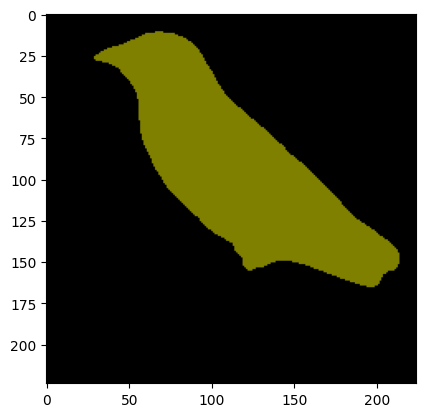

In [10]:
rgb = decode_segmap(om)
plt.imshow(rgb); plt.show()

We have segmented the output of the image. 

That's class 3, with the color (128, 128, 0) - the bird! You can try to change the color of the bird to your preference. 

Please note that the image after segmentation is smaller than the original image as in the preprocessing step the image is resized and cropped.

Next, let's move the hole segmentation process in one function and play with a few more images!

In [11]:
def segment(net, path, show_orig=True, dev='cpu'):
    img = Image.open(path)
    
    if show_orig: plt.imshow(img); plt.axis('off'); plt.show()
    
    trf = T.Compose([T.Resize(640), 
                     #T.CenterCrop(224), 
                     T.ToTensor(), 
                     T.Normalize(mean = [0.485, 0.456, 0.406], 
                                  std = [0.229, 0.224, 0.225])])
              
    inp = trf(img).unsqueeze(0).to(dev)
    if dev=='cuda': net = nn.DataParallel(net) # Use Multi GPUs if available.
    out = net.to(dev)(inp)['out']
    om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
    rgb = decode_segmap(om)
    plt.imshow(rgb); plt.axis('off'); plt.show()

And let's get a new image!

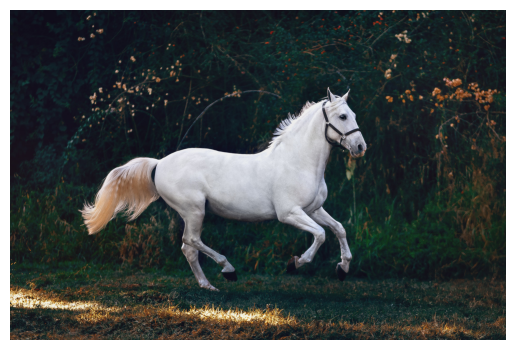

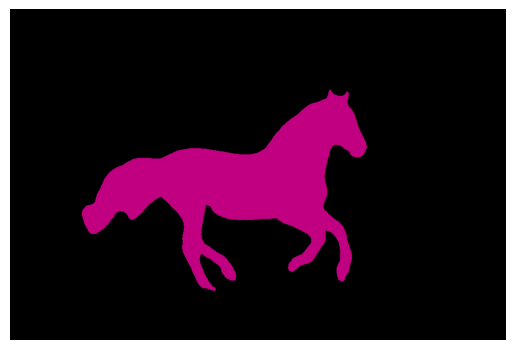

In [12]:
segment(fcn, 'EITB712M/horse.jpg', device)

### DeepLabv3

In [13]:
# load the model
dlab = models.segmentation.deeplabv3_resnet101(pretrained=1).eval()

c:\Users\Jax\Coding\Neuronale-Netze\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to C:\Users\Jax/.cache\torch\hub\checkpoints\deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [01:30<00:00, 2.69MB/s] 


Alright! Now we have god-level segmentation model!<br/>
Let's see how we perform with the same image on this model!

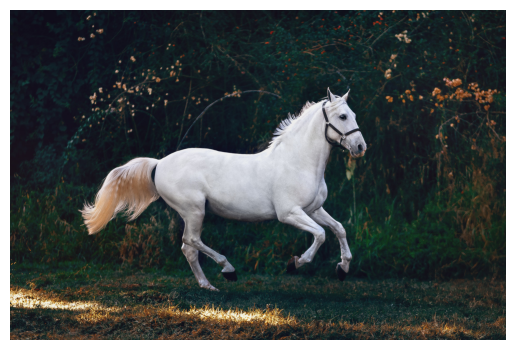

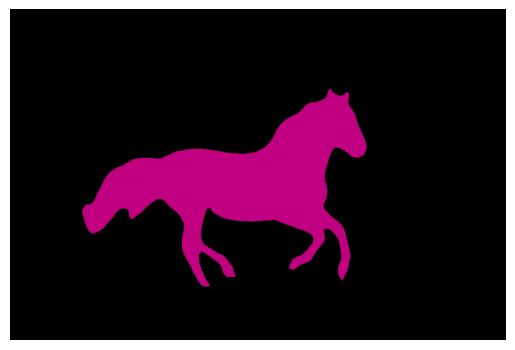

In [14]:
segment(dlab, 'EITB712M/horse.jpg', device)

Yeah! So, there you go! You can see that, the DeepLab model has also classified the image quite nicely! </br>
But if we take a more complex image! Then we start to see model differences! 

Note: As we saw before the output image size is smaller than the original image as the original image is resized and cropped in the preprocessing step.

Let's try that out!

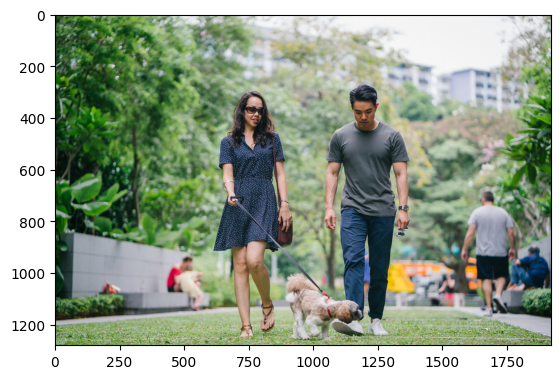

Segmentation Image on FCN


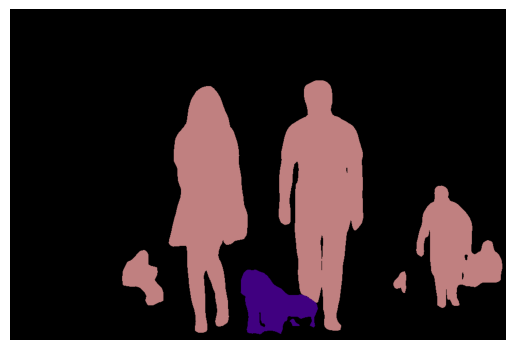

Segmentation Image on DeepLabv3


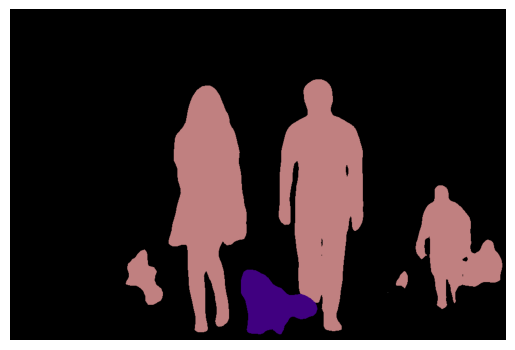

In [15]:
img = Image.open('EITB712M/person.jpg')
plt.imshow(img); plt.show()

print ('Segmentation Image on FCN')
segment(fcn, path='./EITB712M/person.jpg', show_orig=False)

print ('Segmentation Image on DeepLabv3')
segment(dlab, path='./EITB712M/person.jpg', show_orig=False)

Do you remember the play-task of spotting differences within one image? Now, you have the chance to play again. <span style="color:blue">**Try to spot the differences between the images.**</span>

Note: As we saw before the output image size is smaller than the original image as the original image is resized and cropped in the preprocessing step.

<span style="color:blue">**Play around with a few more images and models to see how these perform in different scenarios.**</span>

## Comparison

Now we want see how those two models compare with each other in 3 metrics
- Inference time
- Size of the model

### Inference Time

In [16]:
import time

def infer_time(net, dev, path='EITB712M/person.jpg'):
  img = Image.open(path)
  trf = T.Compose([T.Resize(256), 
                   T.CenterCrop(224), 
                   T.ToTensor(), 
                   T.Normalize(mean = [0.485, 0.456, 0.406], 
                               std = [0.229, 0.224, 0.225])])
  
  inp = trf(img).unsqueeze(0).to(dev)
  
  st = time.time()
  out1 = net.to(dev)(inp)
  et = time.time()
  
  return et - st

**On CPU**

In [17]:
avg_over = 100

fcn_infer_time_list_cpu = [infer_time(fcn, dev='cpu') for _ in range(avg_over)]
fcn_infer_time_avg_cpu = sum(fcn_infer_time_list_cpu) / avg_over

dlab_infer_time_list_cpu = [infer_time(dlab, dev='cpu') for _ in range(avg_over)]
dlab_infer_time_avg_cpu = sum(dlab_infer_time_list_cpu) / avg_over

print ('The Average Inference time on FCN is:     {:.2f}s'.format(fcn_infer_time_avg_cpu))
print ('The Average Inference time on DeepLab is: {:.2f}s'.format(dlab_infer_time_avg_cpu))

The Average Inference time on FCN is:     0.23s
The Average Inference time on DeepLab is: 0.25s


**On GPU**

In [18]:
avg_over = 100

fcn_infer_time_list_gpu = [infer_time(fcn, dev='cuda') for _ in range(avg_over)]
fcn_infer_time_avg_gpu = sum(fcn_infer_time_list_gpu) / avg_over

dlab_infer_time_list_gpu = [infer_time(dlab, dev='cuda') for _ in range(avg_over)]
dlab_infer_time_avg_gpu = sum(dlab_infer_time_list_gpu) / avg_over

print ('The Average Inference time on FCN is:     {:.3f}s'.format(fcn_infer_time_avg_gpu))
print ('The Average Inference time on DeepLab is: {:.3f}s'.format(dlab_infer_time_avg_gpu))

The Average Inference time on FCN is:     0.017s
The Average Inference time on DeepLab is: 0.016s



We can see that in both cases (for GPU and CPU) its taking longer for the DeepLabv3 model, as its a much deeper model as compared to FCN.

Nice! Now, let's try to vizualize the difference in the time taken for the CPU and the GPU.

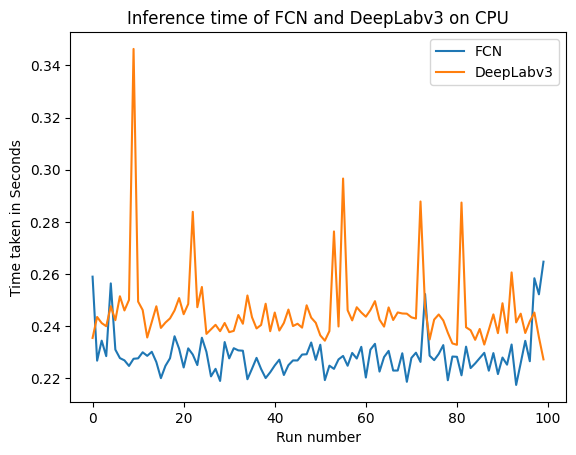

In [19]:
plt.plot(np.arange(np.size(dlab_infer_time_list_cpu)), fcn_infer_time_list_cpu, 
         np.arange(np.size(dlab_infer_time_list_cpu)), dlab_infer_time_list_cpu)
plt.ylabel('Time taken in Seconds')
plt.xlabel('Run number')
plt.title('Inference time of FCN and DeepLabv3 on CPU')
plt.legend(['FCN', 'DeepLabv3'])
plt.show()

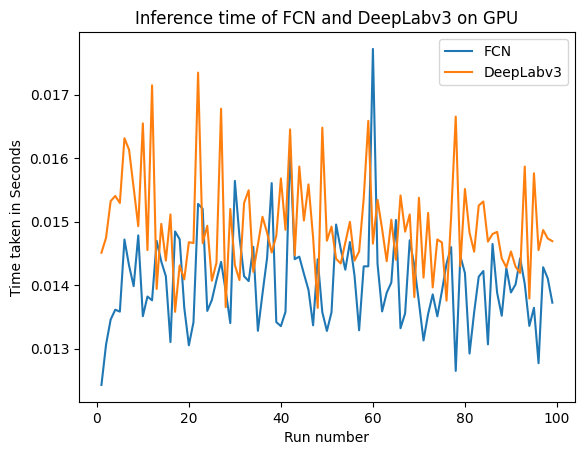

In [20]:
plt.plot(np.arange(np.size(dlab_infer_time_list_gpu))[1:], fcn_infer_time_list_gpu[1:],
         np.arange(np.size(dlab_infer_time_list_gpu))[1:], dlab_infer_time_list_gpu[1:])
plt.ylabel('Time taken in Seconds')
plt.xlabel('Run number')
plt.title('Inference time of FCN and DeepLabv3 on GPU')
plt.legend(['FCN', 'DeepLabv3'])
plt.show()

In [21]:
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.save_checkpoint();'))

import helpers

helpers.prepare_submission(additional=[r"EITB712M"])

<IPython.core.display.Javascript object>

'Abgaben\\82358_Hoegen_Jan_11_20251028_1701.zip'